In [1]:
# Install tqdm if not installed
!pip install tqdm


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==========================================
# MODEL TRAINING
# ==========================================

# Import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# ================================
# Recreate Datasets and Loaders
# ================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset paths
TRAIN_DIR = "../data/processed/train"
VAL_DIR = "../data/processed/val"
TEST_DIR = "../data/processed/test"

# Create datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Loaders recreated successfully.")

Loaders recreated successfully.


In [4]:
# ================================
# Get Number of Classes
# ================================

num_classes = len(train_loader.dataset.classes)
class_names = train_loader.dataset.classes

print("Number of classes:", num_classes)
print("Sample class names:", class_names[:5])

Number of classes: 38
Sample class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [7]:
# ================================
# Define MLP Model
# ================================

class MLP(nn.Module):
    def __init__(self, num_classes):
        super(MLP, self).__init__()
        
        # Flatten image (3x224x224 → 150528)
        self.flatten = nn.Flatten()
        
        # Fully connected layers
        self.model = nn.Sequential(
            nn.Linear(3 * 224 * 224, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.model(x)
        return x

# Create MLP model
mlp_model = MLP(num_classes).to(device)

print("MLP Model created successfully.")

MLP Model created successfully.


In [8]:
# ================================
# Define Loss Function and Optimizer
# ================================

# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer (good default choice)
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

print("Loss function and optimizer defined successfully.")

Loss function and optimizer defined successfully.


In [9]:
# =========================================
# Training Function (One Epoch)
# =========================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        
        # Move data to device (CPU/GPU)
        images = images.to(device)
        labels = labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


In [10]:
# =========================================
# Validation Function (One Epoch)
# =========================================

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation
        
        for images, labels in tqdm(dataloader):
            
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [11]:
# =========================================
# Training Loop
# =========================================

num_epochs = 5  # You can increase later

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # Train for one epoch
    train_loss, train_acc = train_one_epoch(
        mlp_model, train_loader, criterion, optimizer, device
    )

    # Validate for one epoch
    val_loss, val_acc = validate_one_epoch(
        mlp_model, val_loader, criterion, device
    )

    

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")


Epoch [1/5]


100%|██████████| 255/255 [00:36<00:00,  7.02it/s]


Train Loss: 3.9560 | Train Acc: 0.1868
Val   Loss: 2.7889 | Val   Acc: 0.2769

Epoch [2/5]


100%|██████████| 255/255 [00:29<00:00,  8.67it/s]


Train Loss: 3.1046 | Train Acc: 0.2048
Val   Loss: 2.8831 | Val   Acc: 0.2366

Epoch [3/5]


...

Train Loss: 3.1228 | Train Acc: 0.1940
Val   Loss: 2.9248 | Val   Acc: 0.2324

Epoch [4/5]


100%|██████████| 255/255 [00:28<00:00,  8.86it/s]


Train Loss: 3.1932 | Train Acc: 0.1792
Val   Loss: 3.1704 | Val   Acc: 0.1619

Epoch [5/5]


100%|██████████| 255/255 [00:29<00:00,  8.68it/s]

Train Loss: 3.2341 | Train Acc: 0.1663
Val   Loss: 3.1043 | Val   Acc: 0.1896


In [12]:
torch.save(mlp_model.state_dict(), "mlp_model.pth")
print("MLP model saved successfully.")

MLP model saved successfully.


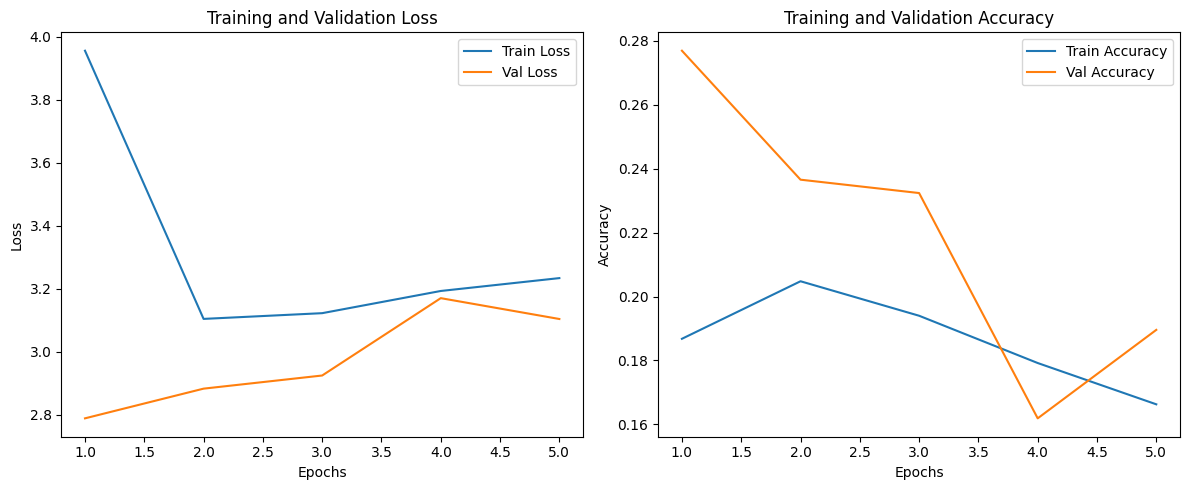

In [13]:
# =========================================
# Plot Training & Validation Curves
# =========================================

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# =========================================
# Simple CNN Model
# =========================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Feature Extraction Layers
        self.features = nn.Sequential(
            
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Classification Layer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [15]:
cnn_model = SimpleCNN(num_classes=num_classes).to(device)

print("CNN model initialized successfully.")

CNN model initialized successfully.


In [17]:
cnn_criterion = torch.nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.0005)

print("Loss function and optimizer defined for CNN.")

Loss function and optimizer defined for CNN.


In [19]:
# ==========================================
# Learning Rate Scheduler
# ==========================================

# Reduce learning rate when validation loss stops improving
cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer,      # optimizer we already defined
    mode='min',         # we monitor validation loss (want it to decrease)
    factor=0.3,         # reduce LR to 30% of current value
    patience=3,         # wait 3 epochs before reducing
    
)

print("Learning rate scheduler initialized successfully.")

Learning rate scheduler initialized successfully.


In [20]:
# ==========================================
# CNN Training Loop
# ==========================================

num_epochs = 22

cnn_train_losses = []
cnn_val_losses = []
cnn_train_accuracies = []
cnn_val_accuracies = []

best_val_acc = 0.0  # Track best validation accuracy

for epoch in range(num_epochs):

    print(f"\nCNN Epoch [{epoch+1}/{num_epochs}]")

    # ======================
    # Training
    # ======================
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, device
    )

    # ======================
    # Validation
    # ======================
    val_loss, val_acc = validate_one_epoch(
        cnn_model, val_loader, cnn_criterion, device
    )

    # ======================
    # Scheduler Step
    # ======================
    cnn_scheduler.step(val_loss)

    # ======================
    # Store metrics
    # ======================
    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    cnn_train_accuracies.append(train_acc)
    cnn_val_accuracies.append(val_acc)

    # ======================
    # Save Best Model
    # ======================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn_model.state_dict(), "cnn_best_model.pth")
        print("Best model saved!")

    # ======================
    # Print Results
    # ======================
    current_lr = cnn_optimizer.param_groups[0]['lr']

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Current Learning Rate: {current_lr}")


CNN Epoch [1/22]


100%|██████████| 255/255 [01:47<00:00,  2.38it/s]


✅ Best model saved!
Train Loss: 2.6667 | Train Acc: 0.3148
Val   Loss: 1.5744 | Val   Acc: 0.5582
Current Learning Rate: 0.0005

CNN Epoch [2/22]


100%|██████████| 255/255 [01:33<00:00,  2.71it/s]


✅ Best model saved!
Train Loss: 2.0286 | Train Acc: 0.4095
Val   Loss: 1.2075 | Val   Acc: 0.6183
Current Learning Rate: 0.0005

CNN Epoch [3/22]


...

✅ Best model saved!
Train Loss: 0.8552 | Train Acc: 0.7065
Val   Loss: 0.3050 | Val   Acc: 0.9063
Current Learning Rate: 0.0005

CNN Epoch [21/22]


100%|██████████| 255/255 [01:24<00:00,  3.01it/s]


✅ Best model saved!
Train Loss: 0.8374 | Train Acc: 0.7122
Val   Loss: 0.3051 | Val   Acc: 0.9079
Current Learning Rate: 0.0005

CNN Epoch [22/22]


100%|██████████| 255/255 [01:24<00:00,  3.03it/s]


✅ Best model saved!
Train Loss: 0.7957 | Train Acc: 0.7213
Val   Loss: 0.2862 | Val   Acc: 0.9082
Current Learning Rate: 0.0005


In [21]:
# Continue training for 3 more epochs

extra_epochs = 3

for epoch in range(extra_epochs):

    print(f"\nExtra Epoch [{epoch+1}/{extra_epochs}]")

    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        cnn_model, val_loader, cnn_criterion, device
    )

    cnn_scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn_model.state_dict(), "cnn_best_model.pth")
        print("✅ Best model updated!")

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")


Extra Epoch [1/3]


100%|██████████| 255/255 [01:36<00:00,  2.64it/s]


✅ Best model updated!
Train Loss: 0.7897 | Train Acc: 0.7236
Val   Loss: 0.2781 | Val   Acc: 0.9150

Extra Epoch [2/3]


100%|██████████| 255/255 [01:28<00:00,  2.87it/s]


Train Loss: 0.7768 | Train Acc: 0.7293
Val   Loss: 0.3234 | Val   Acc: 0.9054

Extra Epoch [3/3]


100%|██████████| 255/255 [01:36<00:00,  2.63it/s]

✅ Best model updated!
Train Loss: 0.7477 | Train Acc: 0.7363
Val   Loss: 0.2632 | Val   Acc: 0.9239


In [22]:
torch.save(cnn_model.state_dict(), "cnn_best_92_plant_disease_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
model = SimpleCNN(num_classes)
model.load_state_dict(torch.load("cnn_plant_disease_model_92.pth"))
model.eval()

In [23]:
val_loss, val_acc = validate_one_epoch(
    cnn_model, val_loader, cnn_criterion, device
)

print("Current Model Validation Accuracy:", val_acc)

100%|██████████| 255/255 [01:28<00:00,  2.89it/s]

Current Model Validation Accuracy: 0.9238528724320335


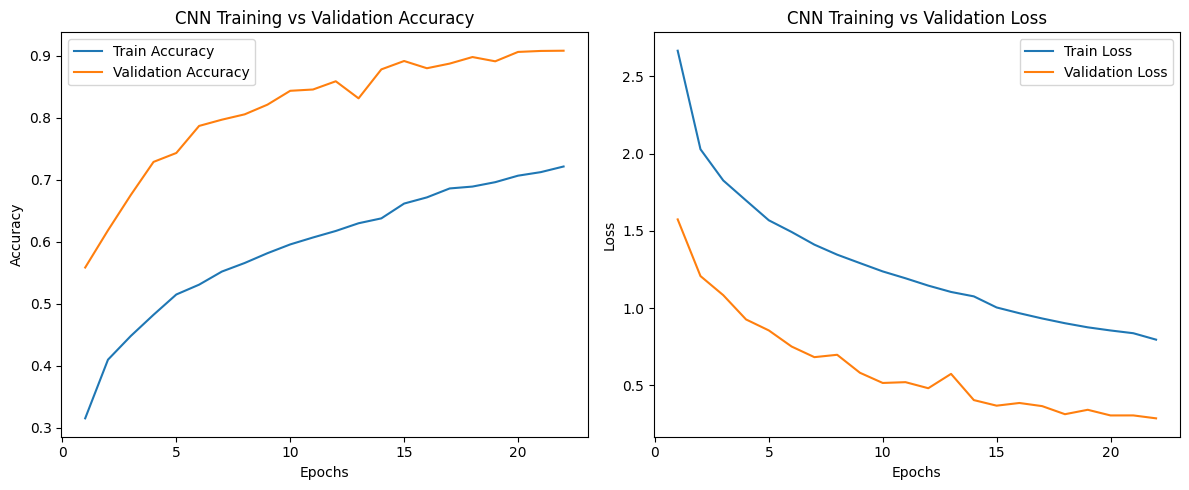

In [30]:
# =========================================
# Plot Training & Validation Curves (CNN)
# =========================================

import matplotlib.pyplot as plt

epochs = range(1, len(cnn_train_losses) + 1)

plt.figure(figsize=(12,5))

# Accuracy Plot (FIRST)
plt.subplot(1,2,1)
plt.plot(epochs, cnn_train_accuracies, label="Train Accuracy")
plt.plot(epochs, cnn_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()

# Loss Plot (SECOND)
plt.subplot(1,2,2)
plt.plot(epochs, cnn_train_losses, label="Train Loss")
plt.plot(epochs, cnn_val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
##for confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [26]:
all_preds = []
all_labels = []

cnn_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [27]:
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (38, 38)


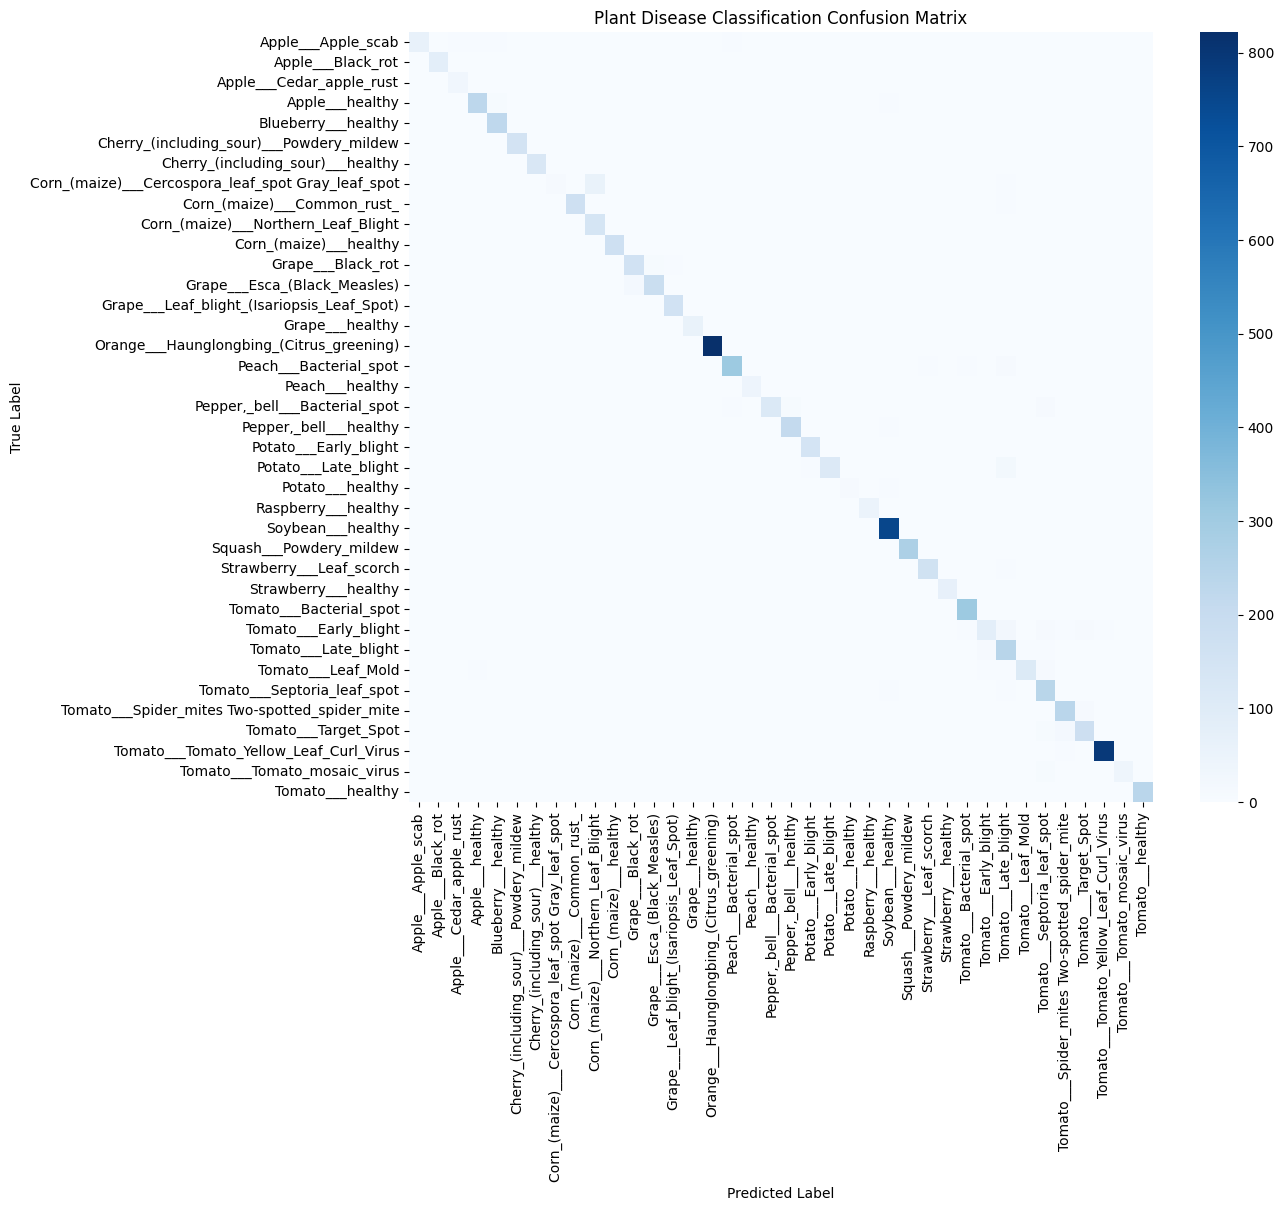

In [28]:
plt.figure(figsize=(12,10))

sns.heatmap(cm,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Plant Disease Classification Confusion Matrix")

plt.show()

In [31]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=class_names)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.86      0.67      0.75        94
                                 Apple___Black_rot       0.98      0.89      0.93        93
                          Apple___Cedar_apple_rust       0.80      0.78      0.79        41
                                   Apple___healthy       0.91      0.93      0.92       246
                               Blueberry___healthy       0.93      1.00      0.96       225
          Cherry_(including_sour)___Powdery_mildew       0.96      0.97      0.97       157
                 Cherry_(including_sour)___healthy       0.93      0.98      0.96       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.13      0.23        76
                       Corn_(maize)___Common_rust_       1.00      0.97      0.98       178
               Corn_(maize)___Northern_Leaf_Blight       0.70      0.98      0.

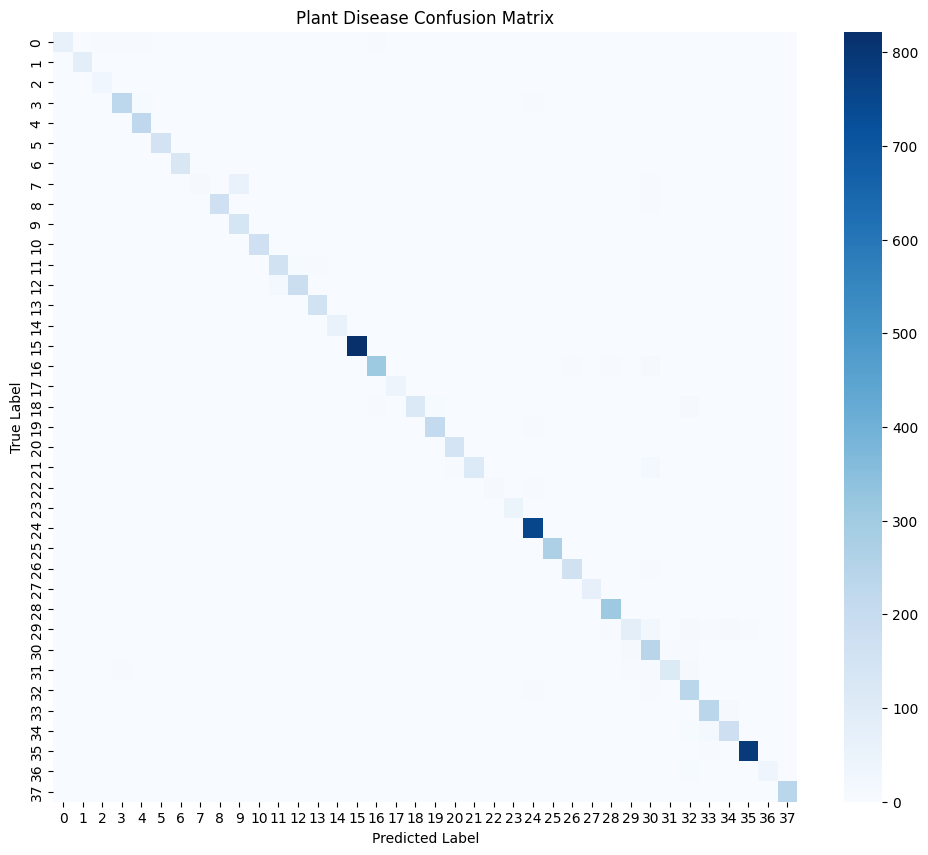

In [32]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Plant Disease Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

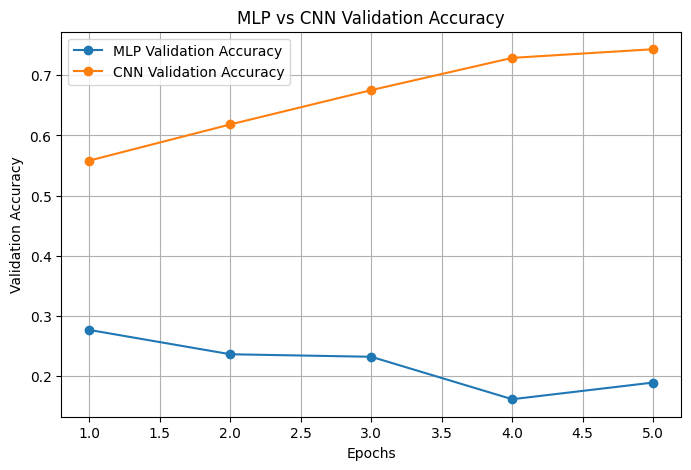

In [33]:
# =========================================
# MLP vs CNN Validation Accuracy Comparison
# =========================================

import matplotlib.pyplot as plt

epochs = range(1, 6)

mlp_acc = val_accuracies              # 5 epochs
cnn_acc = cnn_val_accuracies[:5]      # first 5 epochs of CNN

plt.figure(figsize=(8,5))

plt.plot(epochs, mlp_acc, marker='o', label="MLP Validation Accuracy")
plt.plot(epochs, cnn_acc, marker='o', label="CNN Validation Accuracy")

plt.title("MLP vs CNN Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [34]:
import pandas as pd

data = {
    "Model": ["MLP", "CNN"],
    "Accuracy": [0.19, 0.92],
    "Precision": [0.20, 0.93],
    "Recall": [0.19, 0.92],
    "F1 Score": [0.19, 0.92]
}

comparison_table = pd.DataFrame(data)

print(comparison_table)

  Model  Accuracy  Precision  Recall  F1 Score
0   MLP      0.19       0.20    0.19      0.19
1   CNN      0.92       0.93    0.92      0.92


In [45]:

import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_predictions(model, dataset, num_samples=10):

    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    fig = plt.figure(figsize=(22,11))

    for i, idx in enumerate(indices):

        image, label = dataset[idx]
        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_img)
            probs = F.softmax(outputs, dim=1)
            conf, pred = torch.max(probs, 1)

        pred_label = class_names[pred.item()]
        true_label = class_names[label]
        confidence = conf.item() * 100

        # ---- De-normalize image (important) ----
        img = image.clone().cpu()
        img = img.permute(1,2,0).numpy()

        img = (img - img.min()) / (img.max() - img.min())

        ax = fig.add_subplot(2,5,i+1)
        ax.imshow(img)

        correct = pred_label == true_label
        color = "green" if correct else "red"

        ax.set_title(
            f"Actual: {true_label}\n"
            f"Pred: {pred_label}\n"
            f"Conf: {confidence:.2f}%",
            fontsize=11,
            color=color
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()


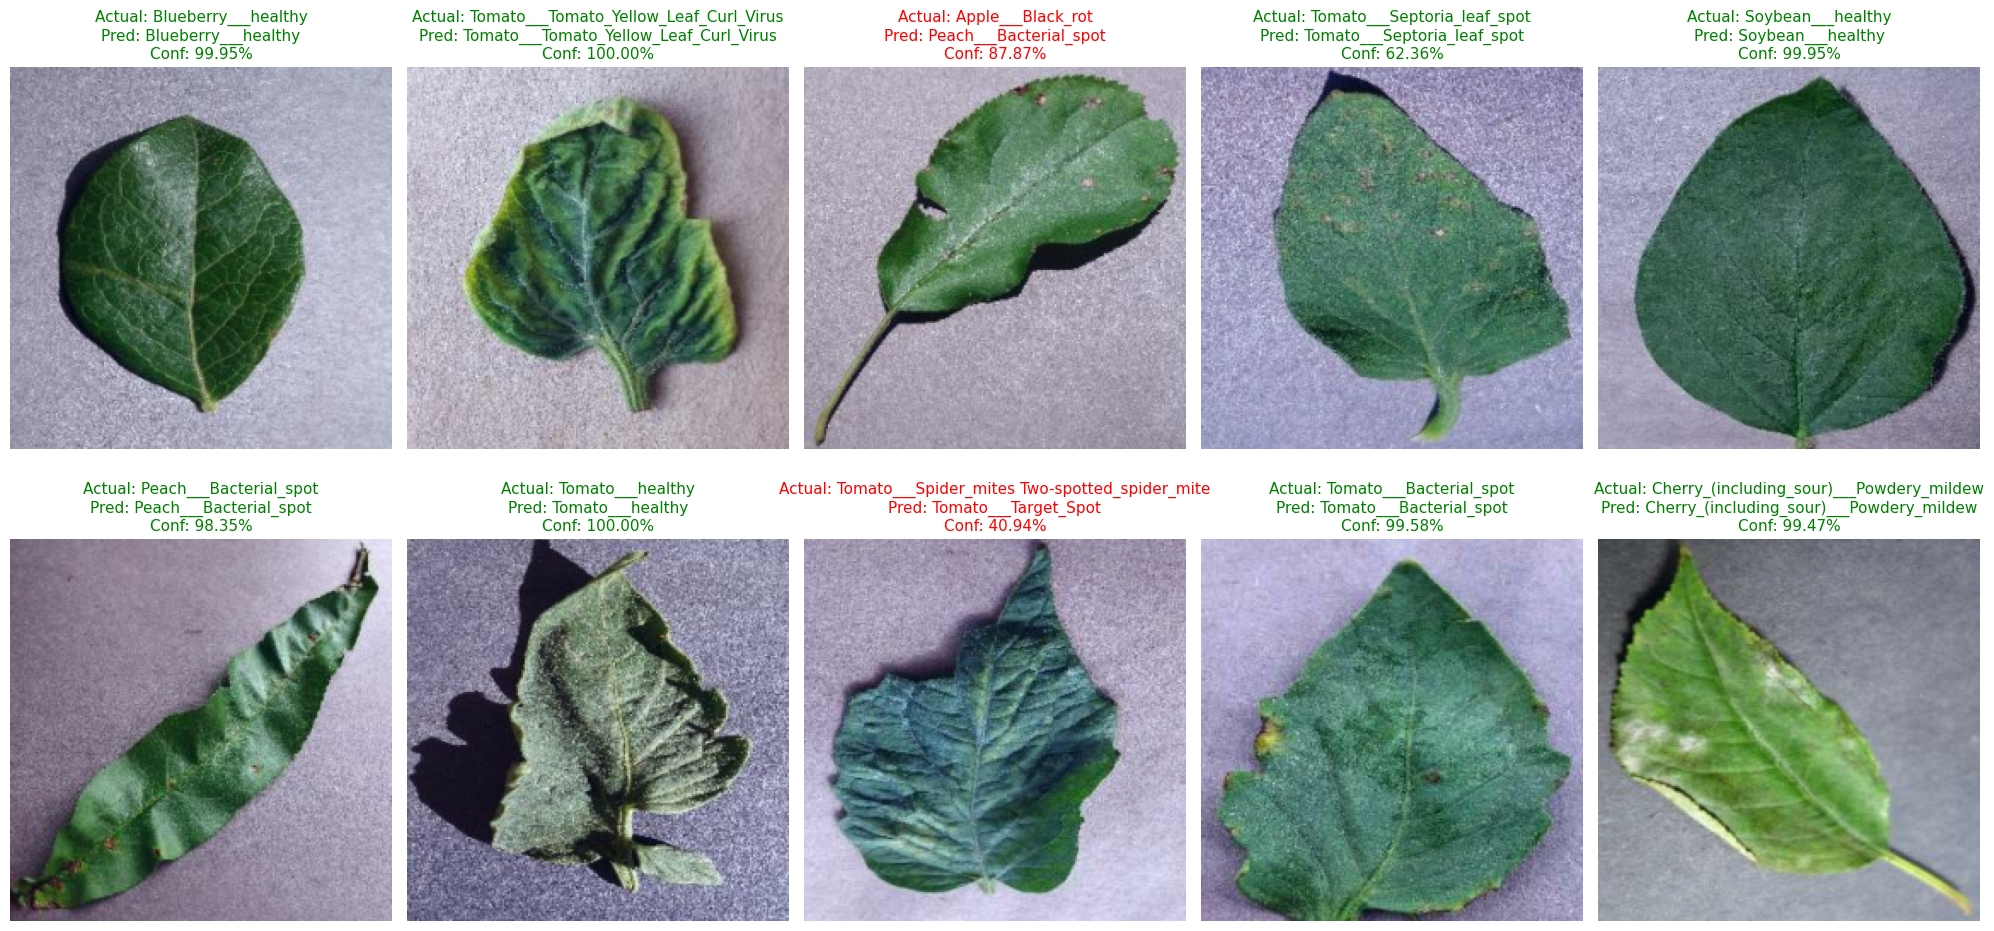

In [44]:
visualize_predictions(cnn_model, val_dataset)

In [46]:
torch.save(cnn_model.state_dict(), "plant_disease_cnn_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [47]:
torch.save(cnn_model, "plant_disease_cnn_full_model.pth")

In [48]:
import os
os.listdir()

['01_dataset_audit.ipynb',
 '02_dataset_split.ipynb',
 '03_preprocessing_and_loader.ipynb',
 '04_modeltraining.ipynb',
 'cnn_best_92_plant_disease_model.pth',
 'cnn_best_model.pth',
 'confusion_matrix.png',
 'mlp_model.pth',
 'plant_disease_cnn_full_model.pth',
 'plant_disease_cnn_model.pth']

In [ ]:
cnn_model.load_state_dict(torch.load("plant_disease_cnn_model.pth"))
cnn_model.eval()